# Basin Rain time-series by Radar Data

### This notebook find weighted av radar-rain for each subbasin
### It does bias-correction for each storm
### It creates text file with timeseries rain data in SWMM format


## Section 1:  Find Radar - Basin Overlap Areas


In [33]:
import os
import scipy.io as sio
from datetime import datetime

import pickle
import numpy as np
import pandas as pd
import geopandas as gpd

import contextily as ctx
from shapely.geometry import Polygon
from shapely.geometry import Point

import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

import rasterio
from rasterio.transform import from_origin

import matplotlib.pyplot as plt

# Functions

In [34]:
def radar_array_to_gdf(rain_array, xll, yll, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.

    Parameters:
    - rain_array (numpy.ndarray): 2D array representing rainfall data.
    - xll (float): X-coordinate of the lower left corner of the grid.
    - yll (float): Y-coordinate of the lower left corner of the grid.
    - cellsize (float): Size of each cell in the grid.

    Returns:
    - radar_gdf (geopandas.GeoDataFrame): GeoDataFrame containing polygon geometries representing rainfall cells.

    This function takes a 2D array representing rainfall data and converts it into a GeoDataFrame with polygon geometries.
    Each cell in the array represents a rainfall value, and the function creates a polygon for each cell with its value
    as an attribute. The coordinate reference system is set to ITM (Israel Transverse Mercator).

    Note: The function adjusts the y-coordinate to handle the reversed north values. In the ITM coordinate system, the
    y-coordinate increases as you move south. Therefore, to align with the common representation of north-oriented grids,
    the function adjusts the y-coordinate calculation to ensure that the polygons are correctly positioned.
    """
    # Convert rainfall data to mm/hour
    rain_array = rain_array 
    
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Define transformation parameters
    transform = from_origin(xll, yll, cellsize, cellsize)
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Calculate y-coordinate
        y_coord = yll + (nrows - i - 1) * cellsize
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = xll + j * cellsize
            x_max = x_min + cellsize
            y_min = y_coord
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf


In [35]:
def create_TimeSeriesData_txt(basins_rain_df):
    """
    Update the TimeSeriesData values of SWMM inp file by using basins_rain_df.

    Args:
        basins_rain_df (DataFrame): DataFrame where each row represents a basin, and each column represents a timestep. 
                                    The values are rain (mm) for each basin in a timestep.
    Returns:
        str: Text representation of the updated timeseries data in the specified format.
    """
    # Initialize an empty string to store the text
    timeseries_text = ''
    # Write the header
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"

    # Iterate over each row in the DataFrame
    for index, row in basins_rain_df.iterrows():
        # Get the basin name
        basin_name = int(row['Basin_name'])

        # Get the first timestamp to use it as the time series name
        first_timestamp = basins_rain_df.columns[1]  # the first timestamp column
        ts_name = first_timestamp.strftime('%Y%m%d') + f"_S{basin_name}"

        # Write the data to the text
        timestamps = basins_rain_df.columns[1:]  # excluding the first column 'Basin_name'
        values = row.values[1:]  # excluding the first column 'Basin_name'
        for ts, value in zip(timestamps, values):
            date_str = ts.strftime('%m/%d/%Y')
            time_str = ts.strftime('%H:%M:%S')
            timeseries_text += f"  {ts_name}      {date_str}    {time_str}   {value:.4f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    
    return timeseries_text


# Load files

In [36]:
# Raanana sub-basin shapefile
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)  # sub-basins poly
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace = True)

In [52]:
# Define the MAT file
radar_filename = r'D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files\20191213'

# Load the MAT file
radar_data = sio.loadmat(radar_filename)
time_i = 2
# Extract the rain data
rain_array_3d = radar_data['event_file'][0][0][0] / 12  # Convert Units: mm
rain_array_2d = rain_array_3d[:, :, time_i]  # Access only one time slice

# The Time 1d values
time_vector = radar_data['event_file'][0][0][1].ravel()
time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
# time_steps = rain_array_3d.shape[-1]
# Define metadata for the array
metadata = {
    'xll': 179000,
    'yll': 648500,
    'cellsize': 500
}

# Convert the array to a GeoDataFrame
radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)

### Radar on Basin plot

<IPython.core.display.Javascript object>


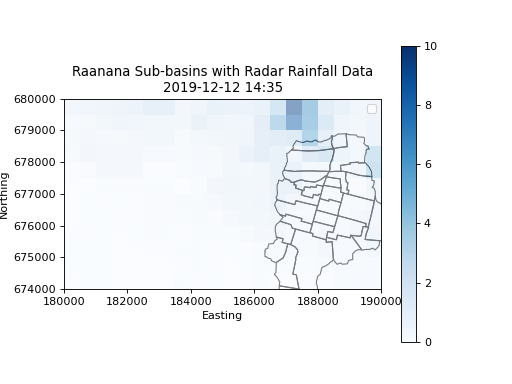

In [53]:
# Define min and max values for the color bar
vmin = 0  # minimum value
vmax = 10  # maximum value

# Plot the Raanana sub-basins
fig, ax = plt.subplots()
raanana_basins_gdf.plot(ax=ax, color='none', edgecolor='black')

# Plot the radar data
radar_gdf.plot(column='rain_value', cmap='Blues', legend=True, ax=ax, alpha=0.5, vmin=vmin, vmax=vmax)

# Define x and y axis limits
x_min, x_max = 180000, 190000  # Replace with your desired x-axis limits
y_min, y_max = 674000, 680000  # Replace with your desired y-axis limits
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])

# Add legend for radar data
plt.legend(['Raanana Sub-basins', 'Rainfall Data'])

# Get the start and end times
time = time_vector[time_i].strftime("%Y-%m-%d %H:%M")


# Title with the time range
plt.title(f'Raanana Sub-basins with Radar Rainfall Data\n{time}')

# Add axis labels
plt.xlabel('Easting')
plt.ylabel('Northing')

# Show the plot
plt.show()


# Create and Save radar_basin_legend_gdf to pkl
## This is the "legend", according to this df the rain for each basin will be defined

In [7]:
# Perform spatial join to find radar cells intersecting with basins
radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
# Create an empty DataFrame to store the results
radar_basin_legend_gdf = pd.DataFrame(columns=['Basin_name', 'radar_cell_num', 'pct', 'basin_geometry', 'radar_geometry'])

# Iterate over each basin in raanana_basins_gdf
for basin_index, basin_row in raanana_basins_gdf.iterrows():
    # Get the basin name and geometry
    basin_name = basin_row['Name']
    basin_geometry = basin_row['geometry']
    
    # Filter radar cells intersecting with the current basin
    intersecting_radar_cells = radar_intersecting_basins[radar_intersecting_basins['index_right'] == basin_index]
    
    # Calculate the total area of the current basin
    basin_area = basin_geometry.area
    
    # Iterate over each intersecting radar cell
    for index, radar_cell in intersecting_radar_cells.iterrows():
        # Get the radar cell number and geometry
        radar_cell_num = radar_cell.name
        radar_geometry = radar_cell['geometry']
        
        # Check if both geometries are valid before calculating intersection
        if basin_geometry.is_valid and radar_geometry.is_valid:
            # Find the intersection between the basin and radar cell
            intersection = basin_geometry.intersection(radar_geometry)
            
            # Check if the intersection is valid
            if intersection.is_valid:
                # Calculate the percentage of intersection
                pct = (intersection.area / basin_area)  # Normalize by basin area
                
                # Add the result to the DataFrame
                radar_basin_legend_gdf = pd.concat([radar_basin_legend_gdf, pd.DataFrame({'Basin_name': [basin_name],
                                                                 'radar_cell_num': [radar_cell_num],
                                                                 'pct': [pct],
                                                                 'basin_geometry': [basin_geometry],
                                                                 'radar_geometry': [radar_geometry]})], ignore_index=True)

In [8]:
radar_basin_legend_gdf

,Basin_name,radar_cell_num,pct,basin_geometry,radar_geometry
0,1,1966,0.102456,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187000 679000, 187500 679000, 187500..."
1,1,1967,0.216619,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187500 679000, 188000 679000, 188000..."
2,1,1968,0.235416,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((188000 679000, 188500 679000, 188500..."
3,1,2005,0.105338,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187000 678500, 187500 678500, 187500..."
4,1,2006,0.197137,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187500 678500, 188000 678500, 188000..."
...,...,...,...,...,...
173,27,2048,0.009101,POLYGON Z ((188566.23900000006 677710.53900000...,"POLYGON ((189000 678000, 189500 678000, 189500..."
174,28,1968,0.101112,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188000 679000, 188500 679000, 188500..."
175,28,1969,0.806755,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188500 679000, 189000 679000, 189000..."
176,28,2007,0.009540,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188000 678500, 188500 678500, 188500..."


In [9]:
# Specify the filename for the pickle file
filename = "radar_basin_legend_gdf.pkl"

# Specify the directory to save the pickle file
directory = r"D:\Development\RESEARCH\Raanana\data\rain_radar\Basin_radar_overlap_pkl"

# Ensure the directory exists, create if it doesn't
os.makedirs(directory, exist_ok=True)

# Save the dictionary as a pickle file in the specified directory
filepath = os.path.join(directory, filename)
with open(filepath, "wb") as f:
    pickle.dump(radar_basin_legend_gdf, f)

# Section 2 - Cumpute Radar-Rainfall for each Basin

In [10]:
# # List of events and biases

# event_and_bias_l = [
#     ("20120113", 1.56), ("20130106", 1.13), ("20141214", 0.92), ("20151007", 0.75), 
#     ("20151027", 0.6), ("20151028", 0.6), ("20151107", 0.61), ("20151214", 1.01), 
#     ("20151218", 0.87), ("20160108", 1.24), ("20160126", 1.46), ("20161213", 1.26), 
#     ("20161219", 1.17), ("20161227", 1.2), ("20171121", 0.9), ("20171224", 1.33), 
#     ("20180101", 1.29), ("20180105", 1.3), ("20180114", 1.27), ("20180123", 1.43), 
#     ("20180125", 1.48), ("20180213", 0.7), ("20181207", 0.81), ("20191213", 0.87), 
#     ("20191227", 0.79), ("20200119", 1.02)
# ]
# # Extract the event date and BIAS using the index
# event_date, BIAS = event_and_bias_l[event_i]
# # Construct the radar filename
# radar_filename = rf'D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files_large_domain\{event_date}.mat'
# # Load the MAT file
# radar_data = sio.loadmat(radar_filename)
# print(f"Event Date: {event_date}")

# Create the rain-basin data
## running on each storm (matfile), utilize rain gauge bias correction
### output:
### 1. basins_rain_dfs_dict with key: storm date, and value: rain df for each basin (row) and time step (col)
### 2. optional: text file in swmm inp file time serie format

In [11]:
def process_radar_data(radar_data, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf):
    # First load the radar data
    rain_array_3d = radar_data['event_file'][0][0][0]
    rain_array_3d = rain_array_3d / 12  # Convert Units: mm/h to mm/5min
    rain_array_3d = rain_array_3d / BIAS  # Bias correction

    time_vector = radar_data['event_file'][0][0][1].ravel()
    time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
    time_steps = rain_array_3d.shape[-1]

    time_diff = time_vector[1:] - time_vector[:-1]
    is_5_min_interval = (time_diff == pd.Timedelta(minutes=5)).all()

    if not is_5_min_interval:
        raise ValueError("Time differences are not exactly 5 minutes. Please check the time vector.")

    radar_gdf_list = []

    for time in range(time_steps):
        rain_array_2d = rain_array_3d[:, :, time]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])

    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector

    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)

    resampled_dfs = []
    date = basins_rain_df.columns[1].strftime('%Y%m%d')  # Format date as YYYYMMDD
    for i, row in basins_rain_df.iterrows():
        basin_name = int(row['Basin_name'])
        rainfall_values = row.drop('Basin_name').values
        plt.plot(time_vector, rainfall_values, label=basin_name)

    plt.ylim(0, 50)
    plt.grid()
    plt.xlabel('Time')
    plt.ylabel('Rainfall (mm)')
    plt.title('Radar Rainfall by Basin', fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha='right')
    plt.subplots_adjust(bottom=0.2)
    plt.legend(title='Basin Name', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()
    
    return basins_rain_df


In [12]:
def resampling_process_radar_data(radar_data, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf):
    # First load the radar data
    rain_array_3d = radar_data['event_file'][0][0][0]
    rain_array_3d = rain_array_3d / 12  # Convert Units: mm/h to mm/5min
    rain_array_3d = rain_array_3d / BIAS  # Bias correction

    time_vector = radar_data['event_file'][0][0][1].ravel()
    time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
    time_steps = rain_array_3d.shape[-1]

    time_diff = time_vector[1:] - time_vector[:-1]

    radar_gdf_list = []

    for time in range(time_steps):
        rain_array_2d = rain_array_3d[:, :, time]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])

    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector

    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)

    resampled_dfs = []
    date = basins_rain_df.columns[1].strftime('%Y%m%d')  # Format date as YYYYMMDD
    for i, row in basins_rain_df.iterrows():
        basin_name = int(row['Basin_name'])
        rainfall_values = row.drop('Basin_name').values
        plt.plot(time_vector, rainfall_values, label=basin_name)

    plt.ylim(0, 50)
    plt.grid()
    plt.xlabel('Time')
    plt.ylabel('Rainfall (mm)')
    plt.title('Radar Rainfall by Basin', fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha='right')
    plt.subplots_adjust(bottom=0.2)
    plt.legend(title='Basin Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    for basin, row in basins_rain_df.iterrows():
        basin_num = basin + 1
        df = basins_rain_df.iloc[basin].to_frame()[1:]
        df.index = pd.to_datetime(df.index)
        resampled_basin_df = df.resample('5T').sum().transpose()
        resampled_basin_df['Basin_name'] = basin_num
        # Extract the "Basin_name" column as a separate Series
        basin_name_series = resampled_basin_df['Basin_name']
        # Drop the "Basin_name" column from the DataFrame
        resampled_basin_df.drop(columns=['Basin_name'], inplace=True)
        # Insert the "Basin_name" column at the beginning of the DataFrame
        resampled_basin_df.insert(0, 'Basin_name', basin_name_series)
        # Append the resampled DataFrame to the list
        resampled_dfs.append(resampled_basin_df)
    # Concatenate the DataFrames in the list along the rows axis (vertically)
    basins_rain_df = pd.concat(resampled_dfs, axis=0)


    return basins_rain_df

Event Date: 20120113


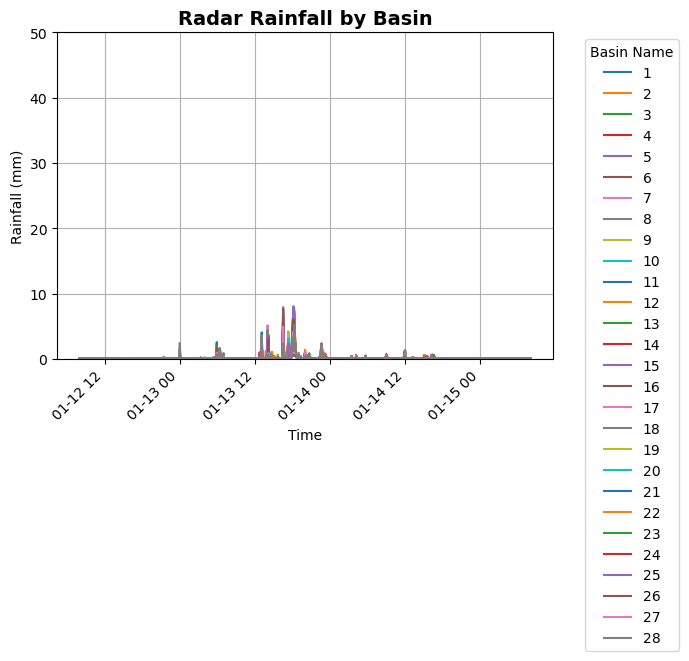

Event Date: 20130106


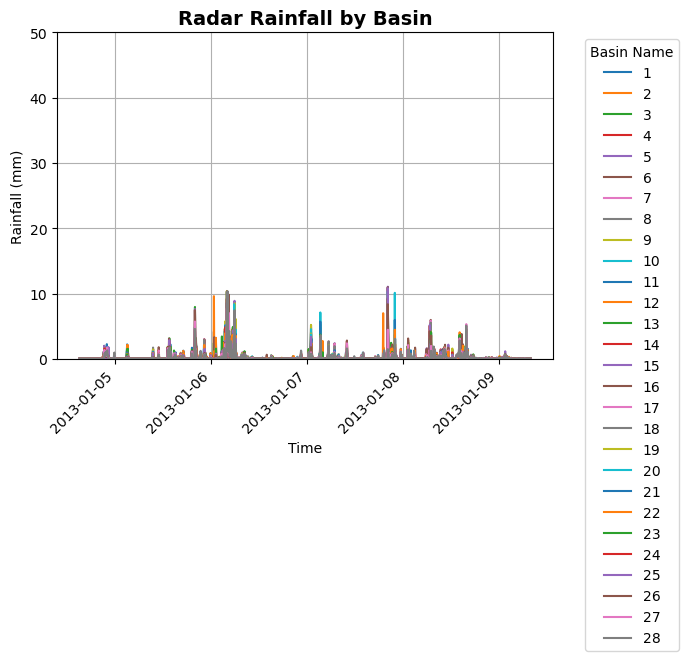

Event Date: 20141214


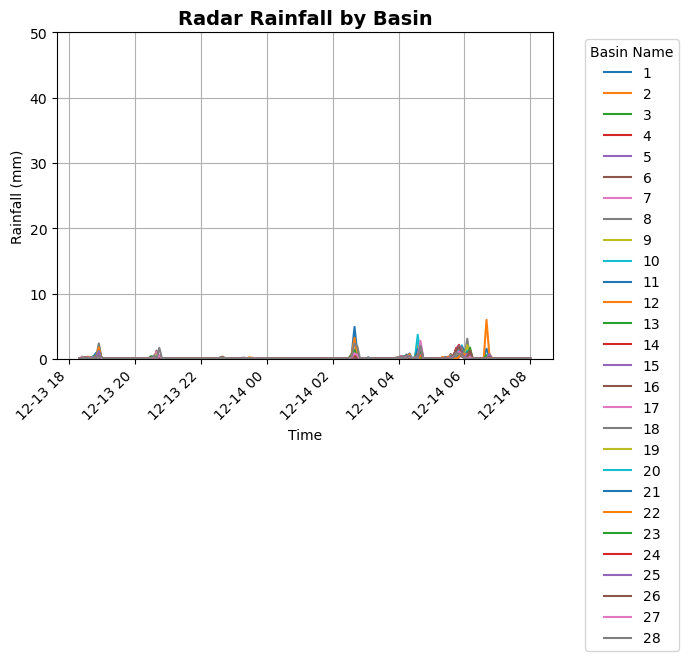

Event Date: 20151007


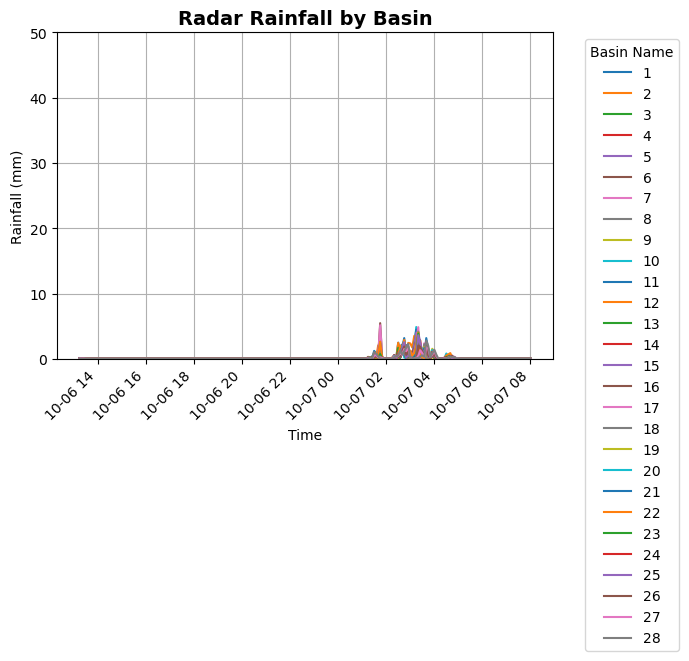

Event Date: 20151027


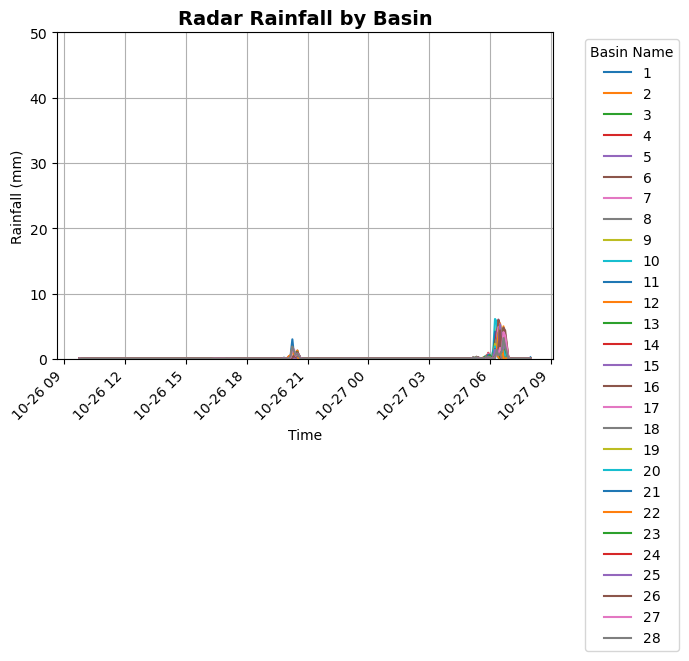

Event Date: 20151028


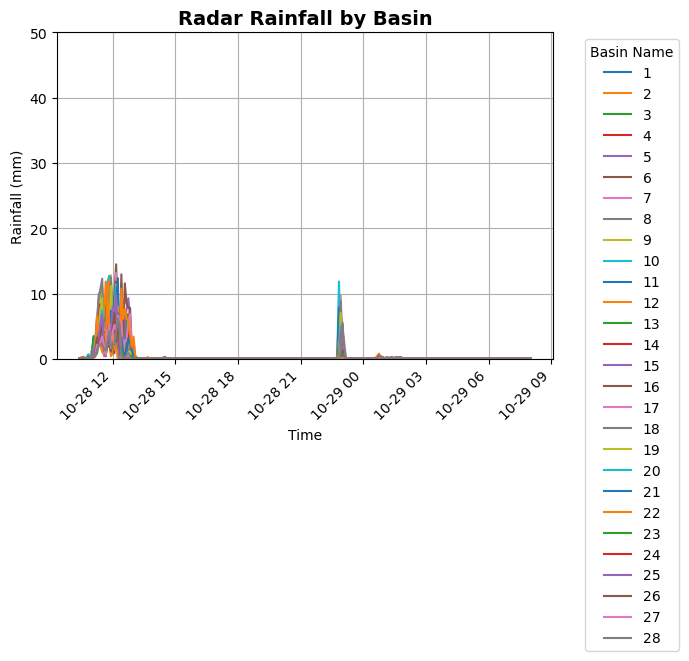

Event Date: 20151107


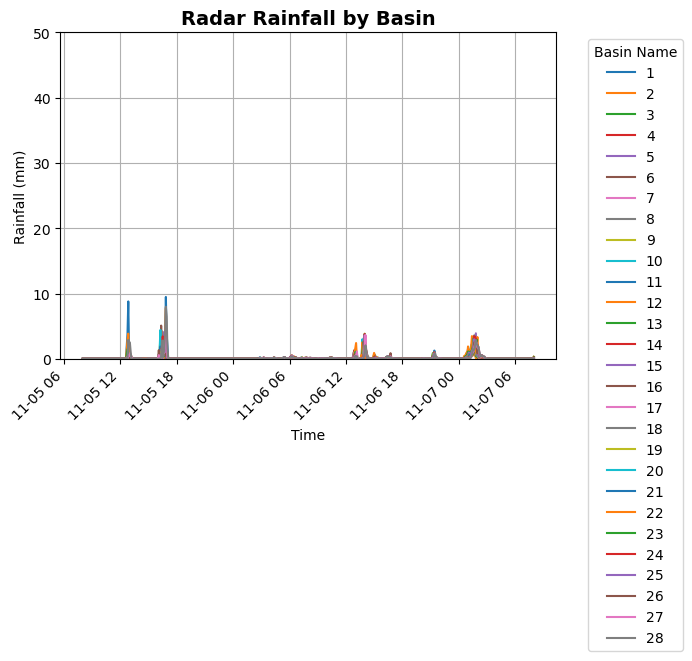

Event Date: 20151214


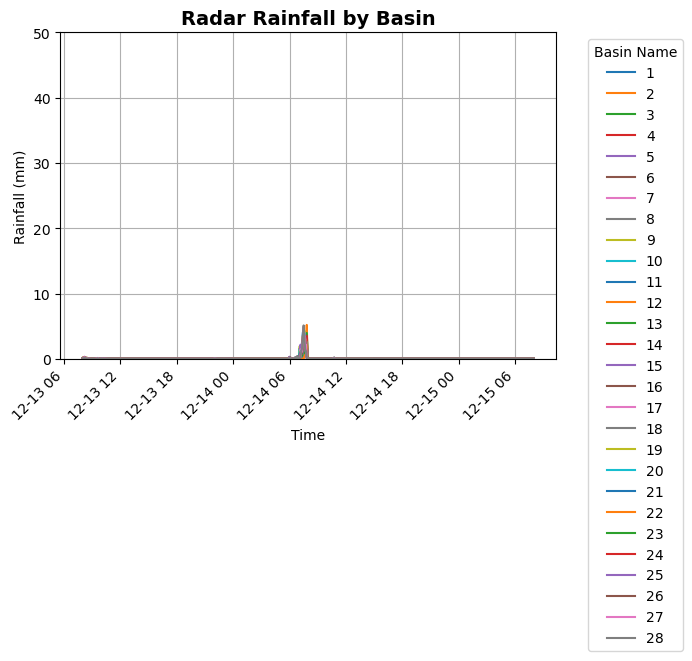

Event Date: 20151218


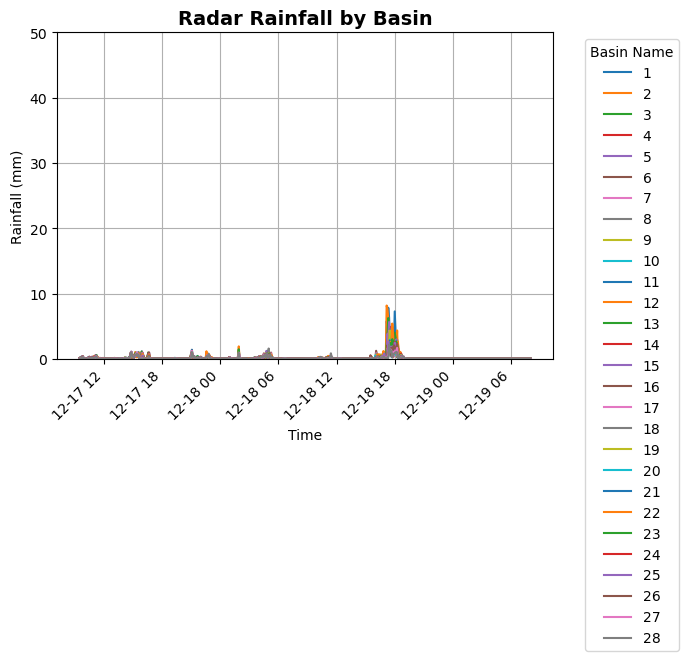

Event Date: 20160108


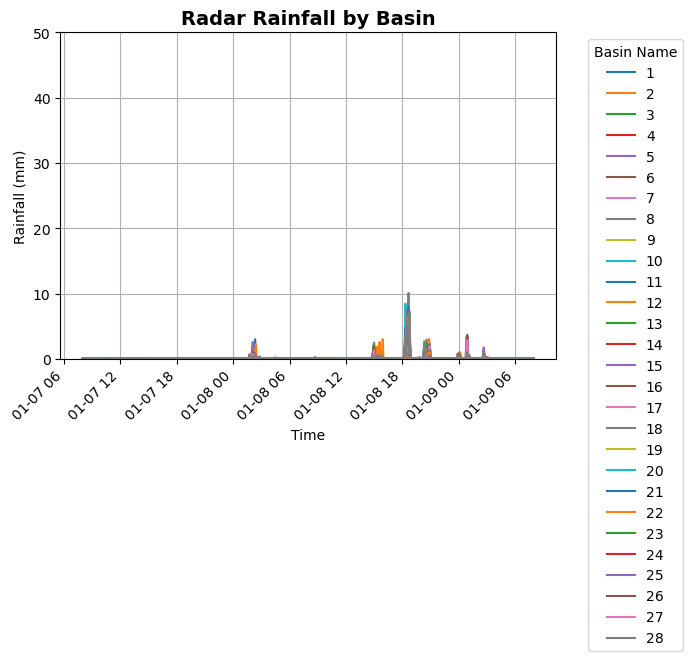

Event Date: 20160126


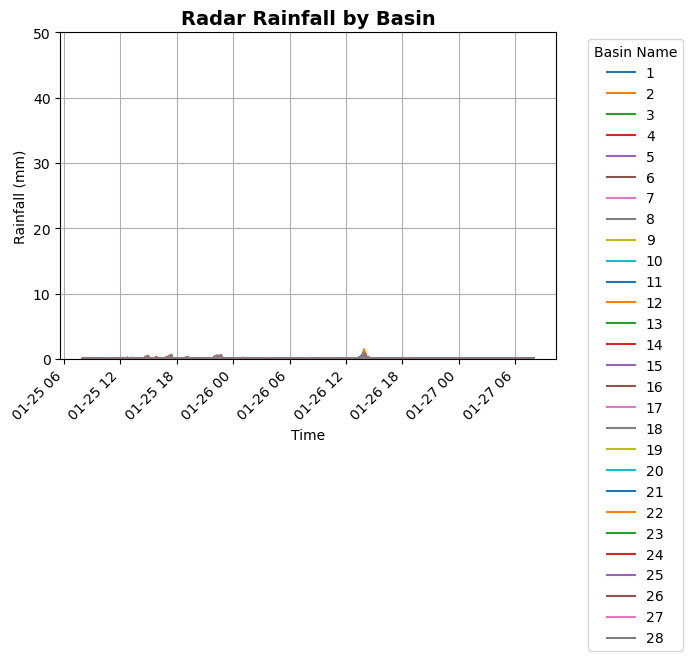

Event Date: 20161213


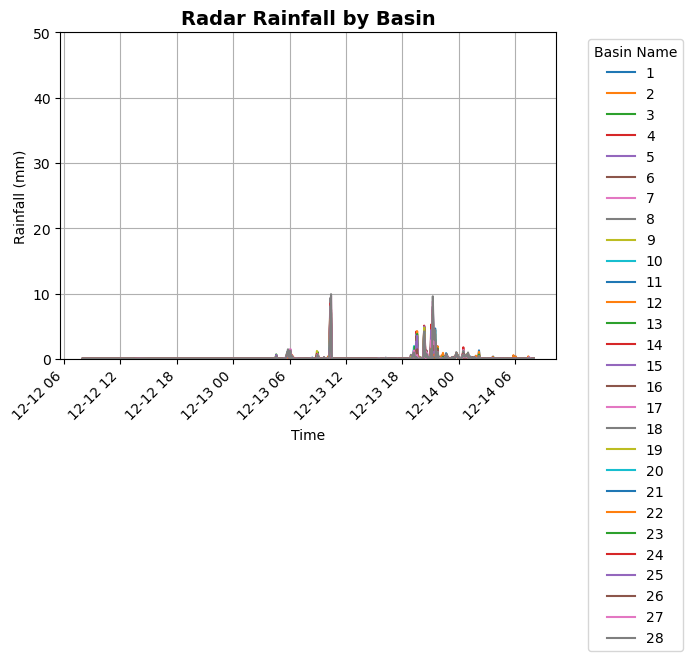

Event Date: 20161219


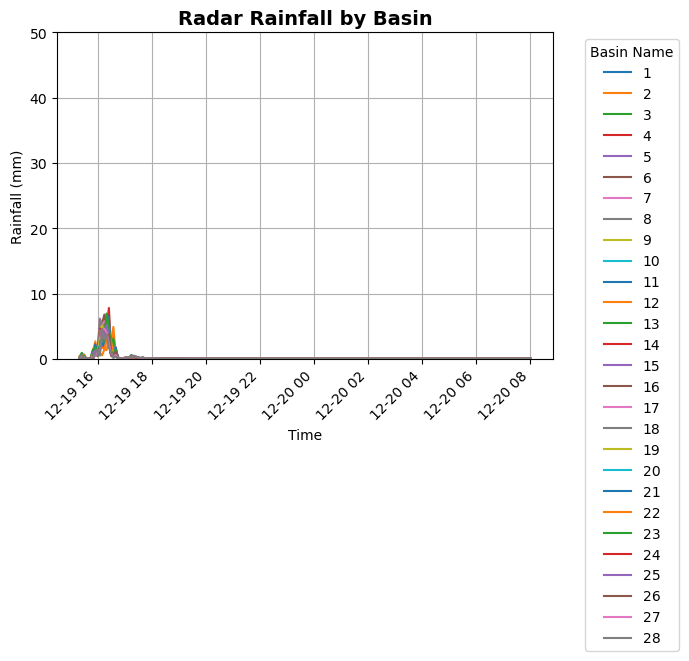

Event Date: 20161227


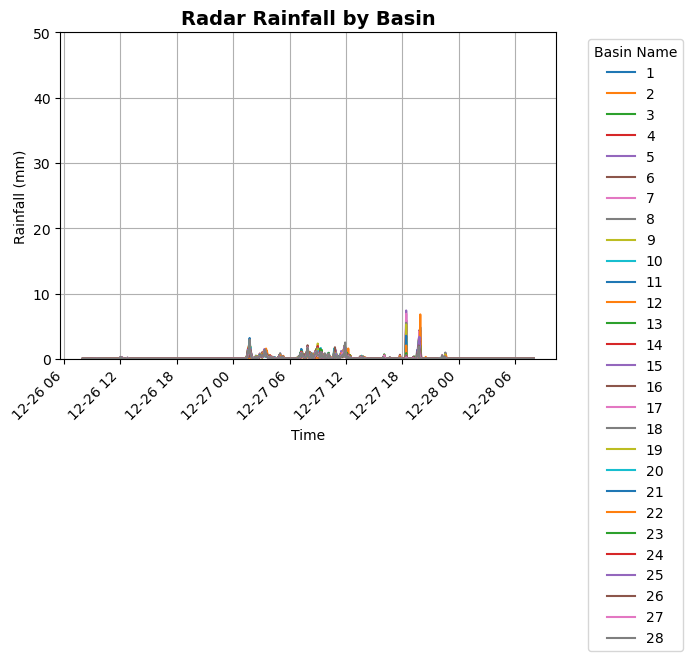

Event Date: 20171121


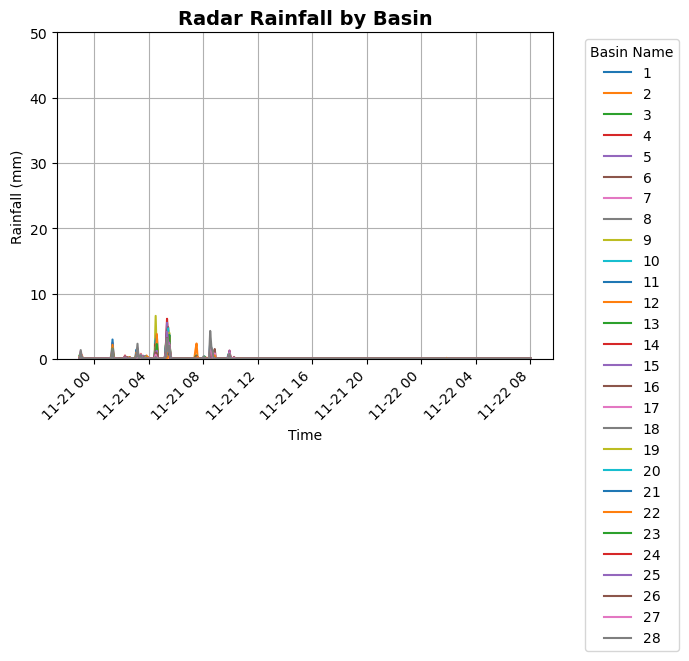

Event Date: 20171224


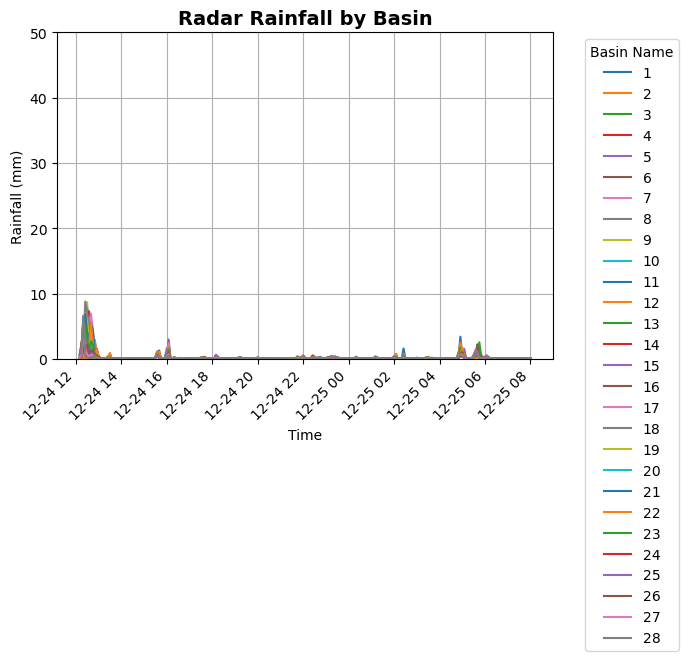

Event Date: 20180101


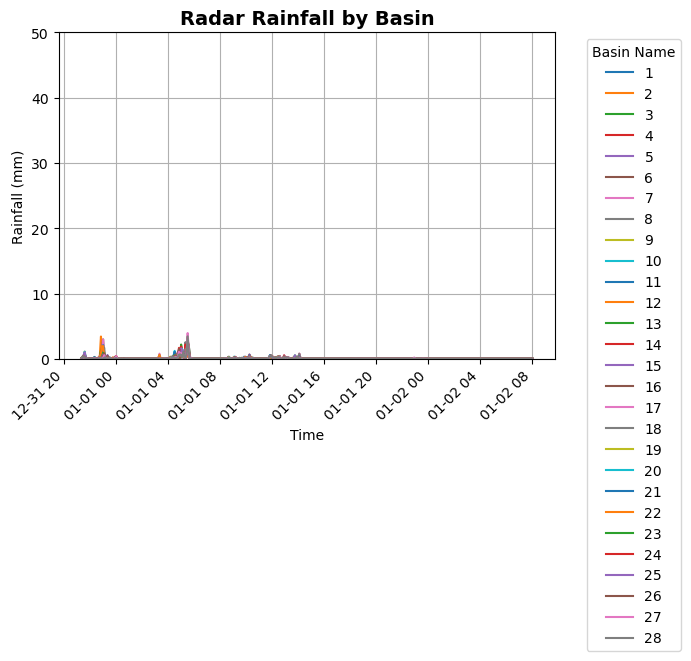

Event Date: 20180105


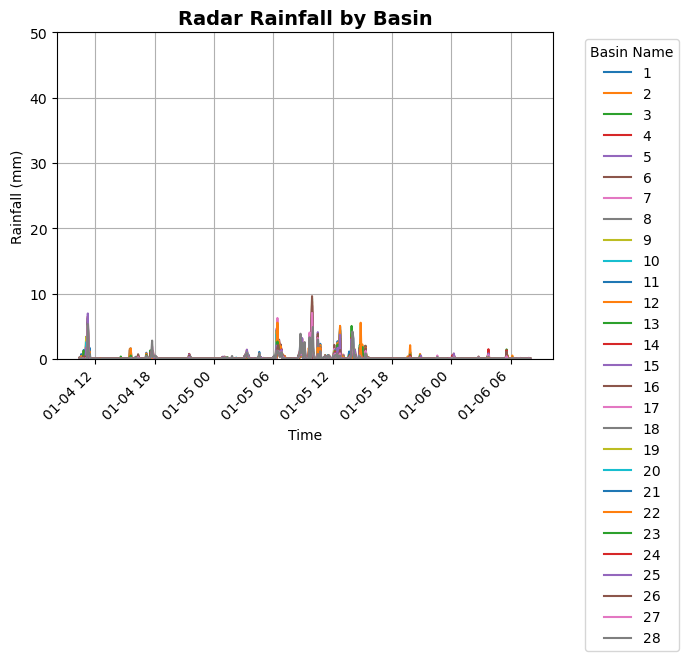

Event Date: 20180114


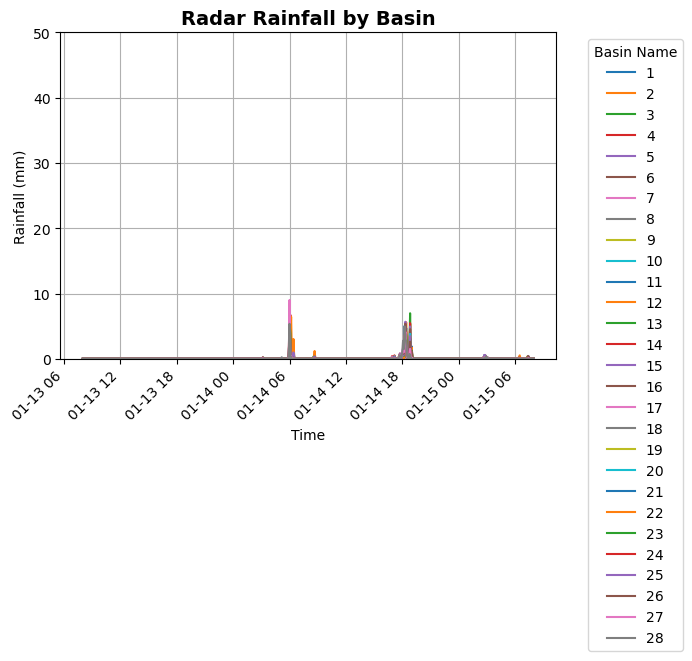

Event Date: 20180123


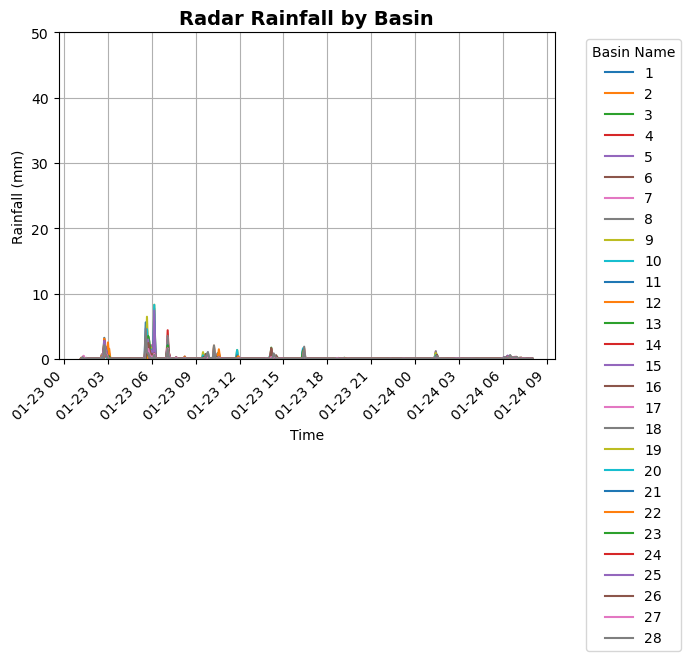

Event Date: 20180125


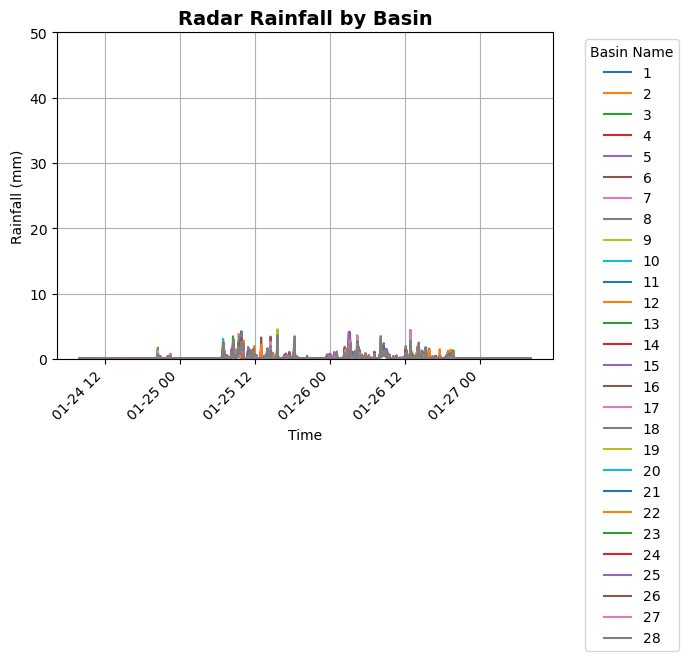

Event Date: 20180213


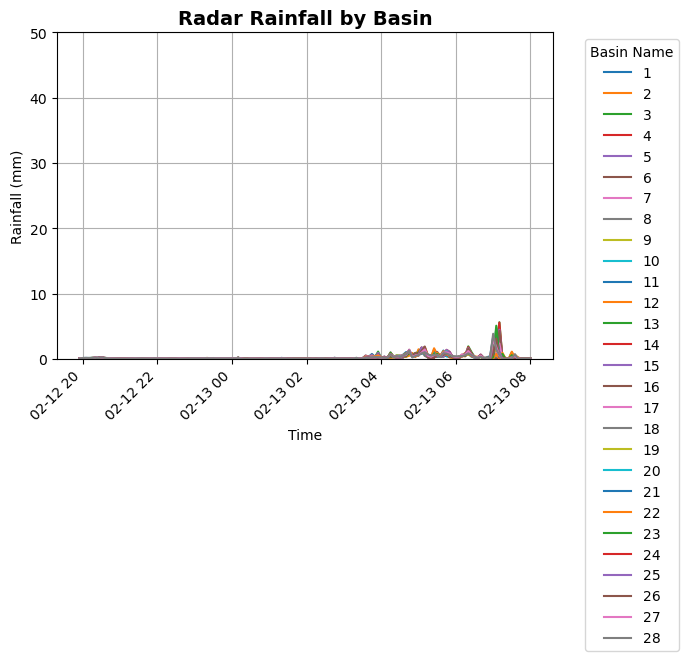

Event Date: 20181207


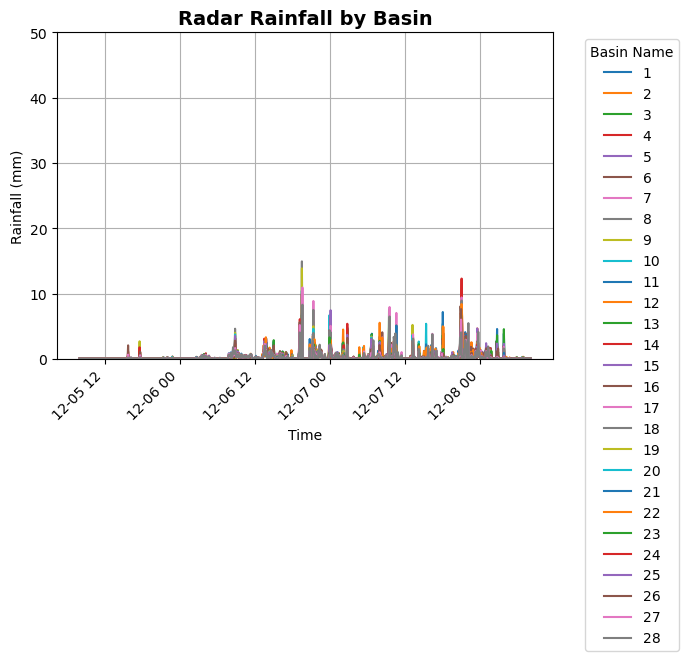

Event Date: 20191213


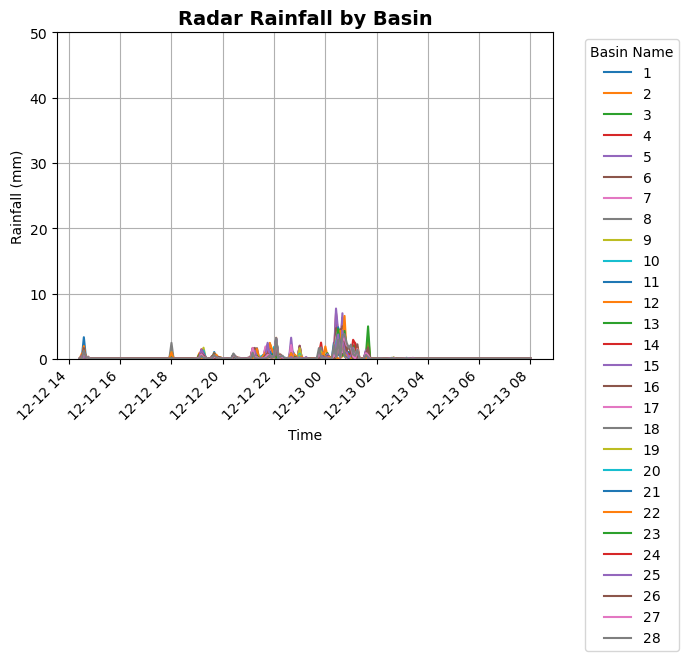

Event Date: 20191227


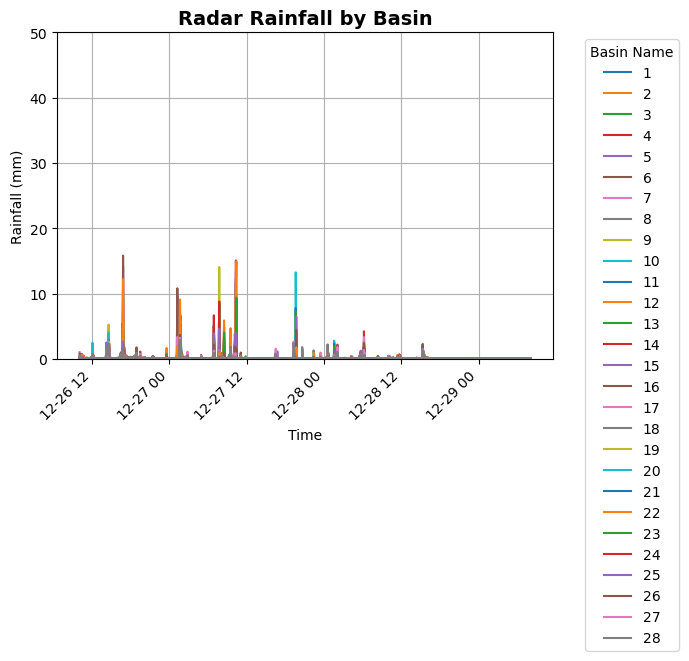

Event Date: 20200119


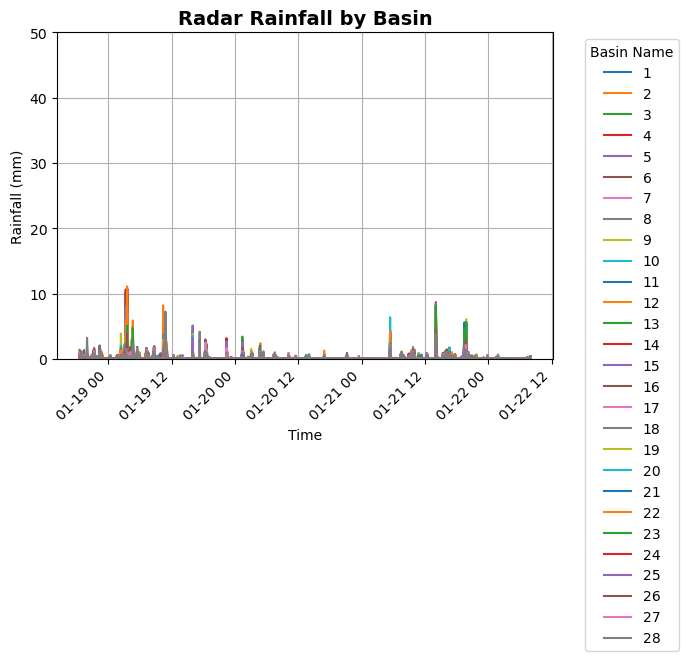

In [13]:

# List of events and biases
event_and_bias_l = [
    ("20120113", 1.56), ("20130106", 1.13), ("20141214", 0.92), ("20151007", 0.75), 
    ("20151027", 0.6), ("20151028", 0.6), ("20151107", 0.61), ("20151214", 1.01), 
    ("20151218", 0.87), ("20160108", 1.24), ("20160126", 1.46), ("20161213", 1.26), 
    ("20161219", 1.17), ("20161227", 1.2), ("20171121", 0.9), ("20171224", 1.33), 
    ("20180101", 1.29), ("20180105", 1.3), ("20180114", 1.27), ("20180123", 1.43), 
    ("20180125", 1.48), ("20180213", 0.7), ("20181207", 0.81), ("20191213", 0.87), 
    ("20191227", 0.79), ("20200119", 1.02)
]

# Define the folder paths
folder_path = r"D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files"
save_folder_path = r"D:\Development\RESEARCH\Raanana\data\rain_radar\TXT_file_by_subbasin"

metadata = {
    'xll': 179000,
    'yll': 648500,
    'cellsize': 500
}

basins_rain_dfs_dict = {}
# Iterate over each event and bias value
for event_date, BIAS in event_and_bias_l:
    # Construct the full file path
    radar_filename = os.path.join(folder_path, f"{event_date}.mat")
    
    # Load radar data
    radar_data = sio.loadmat(radar_filename)
    print(f"Event Date: {event_date}")
    
    # Conditional check for specific date
    if event_date == "20191227":
        # Call the resampling_process_radar_data function
        basins_rain_df = resampling_process_radar_data(radar_data, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf)
    else:
        # Call the process_radar_data function
        basins_rain_df = process_radar_data(radar_data, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf)
    # Create the text representation of the DataFrame
    timeseries_text = create_TimeSeriesData_txt(basins_rain_df)
    
    # Save the basins_rain_dfs in dict for later use in cross-validation codes
    event_date_formatted = event_date.split('.')[0]
    event_date_formatted = f"{event_date_formatted[:4]}_{event_date_formatted[4:6]}_{event_date_formatted[6:]}"   
    # Store the dataframe in the dictionary
    basins_rain_dfs_dict[event_date_formatted] = basins_rain_df

    # Define the filename for saving
    txt_filename = os.path.join(save_folder_path, f"{event_date_formatted}.txt")
    # Save the text to a text file
    with open(txt_filename, 'w') as f:
        f.write(timeseries_text)


In [14]:
# Specify the filename for the pickle file
filename = "Basin_radar_overlap_pkl.pkl"

# Specify the directory to save the pickle file
directory = r"D:\Development\RESEARCH\Raanana\data\rain_radar\Basin_radar_overlap_pkl"

# Ensure the directory exists, create if it doesn't
os.makedirs(directory, exist_ok=True)
    
# Save the dictionary as a pickle file in the specified directory
filepath = os.path.join(directory, filename)
with open(filepath, "wb") as f:
    pickle.dump(basins_rain_dfs_dict, f)

In [25]:
basins_rain_df = basins_rain_dfs_dict['2012_01_13']

In [27]:
basins_rain_df.iloc[0][1:]

2012-01-12 08:00:00    0.0
2012-01-12 08:05:00    0.0
2012-01-12 08:10:00    0.0
2012-01-12 08:15:00    0.0
2012-01-12 08:20:00    0.0
                      ... 
2012-01-15 07:40:00    0.0
2012-01-15 07:45:00    0.0
2012-01-15 07:50:00    0.0
2012-01-15 07:55:00    0.0
2012-01-15 08:00:00    0.0
Name: 0, Length: 865, dtype: float64

In [28]:
basins_rain_df.iloc[0][1:].sum()

71.83725079534625

# Plot for fun

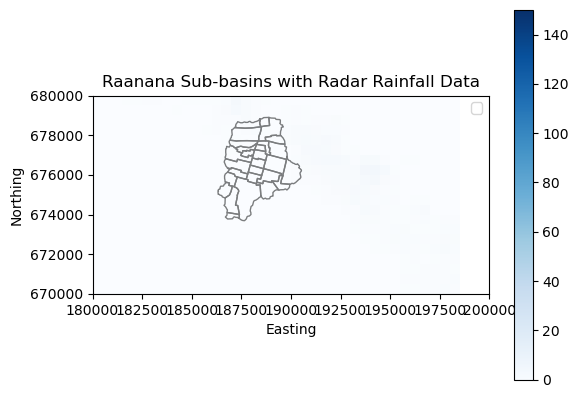

In [15]:
import matplotlib.pyplot as plt

# Define min and max values for the color bar
vmin = 0  # minimum value
vmax = 150  # maximum value

# Plot the Raanana sub-basins
fig, ax = plt.subplots()
raanana_basins_gdf.plot(ax=ax, color='none', edgecolor='black')

# Plot the radar data
radar_gdf.plot(column='rain_value', cmap='Blues', legend=True, ax=ax, alpha=0.5, vmin=vmin, vmax=vmax)

# Define x and y axis limits
x_min, x_max = 180000, 200000  # Replace with your desired x-axis limits
y_min, y_max = 670000, 680000  # Replace with your desired y-axis limits
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])

# Add legend for radar data
plt.legend(['Raanana Sub-basins', 'Rainfall Data'])

# Add title and axis labels
plt.title('Raanana Sub-basins with Radar Rainfall Data')
plt.xlabel('Easting')
plt.ylabel('Northing')

# Show the plot
plt.show()


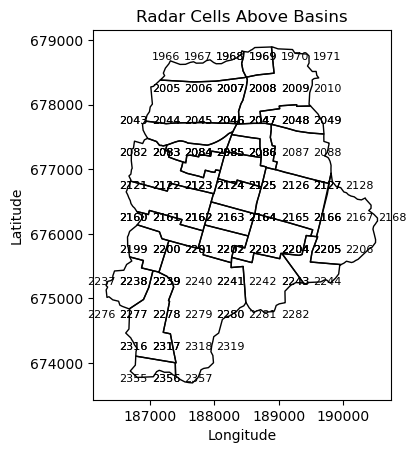

In [16]:
import matplotlib.pyplot as plt

# Plot the basins
raanana_basins_gdf.plot(edgecolor='black', facecolor='none')

# Plot the radar cells above the basins
for index, row in radar_basin_legend_gdf.iterrows():
    # Get the radar cell number and its coordinates
    radar_cell_num = row['radar_cell_num']
    x, y = row['radar_geometry'].centroid.x, row['radar_geometry'].centroid.y
    
    # Plot the radar cell number above the basin
    plt.text(x, y, str(radar_cell_num), fontsize=8, ha='center', va='center')

# Set plot title and labels
plt.title('Radar Cells Above Basins')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Display the plot
plt.show()
